# Anime Review Sentiment Analysis

Binary sentiment classification on MyAnimeList reviews, comparing a TF-IDF 
baseline against a fine-tuned RoBERTa model.

## 1. Data loading

Source: MyAnimeList Comment Dataset V2 (Kaggle), 224,641 reviews scraped 
since 2006. Only four columns are loaded, since the full file is 599 MB and 
most of its metadata (URLs, author names, reaction counts) is irrelevant here.

A 40,000-review sample is drawn to keep iteration fast.

In [13]:
import pandas as pd

USEFUL_COLUMNS = ["workName", "overallRating", "review", "recommendationStatus"]

df_full = pd.read_csv("data/reviews.csv", usecols=USEFUL_COLUMNS)
df = df_full.sample(n=40000, random_state=42).reset_index(drop=True)

print(f"Full dataset: {len(df_full):,} reviews")
print(f"Working sample: {len(df):,} reviews")

Full dataset: 224,641 reviews
Working sample: 40,000 reviews


## 2. Labeling strategy

Ratings run from 1 to 10, so the binary labels have to be defined manually. 
Two constraints pull in opposite directions: the threshold should mean 
something (a 7 is not a negative review), and the classes should not be too 
imbalanced.

Cutting at the median would give balanced classes but nonsensical labels, 
since the median sits at 8. Cutting at the midpoint keeps every review but 
treats lukewarm ratings as strong opinions.

The chosen approach drops the ambiguous middle: 1 to 4 is negative, 8 to 10 
is positive, 5 to 7 is discarded.

In [14]:
CLEAR_NEGATIVE = 4
CLEAR_POSITIVE = 8

df_labeled = df[
    (df["overallRating"] <= CLEAR_NEGATIVE) | (df["overallRating"] >= CLEAR_POSITIVE)
].copy()
df_labeled["label"] = (df_labeled["overallRating"] >= CLEAR_POSITIVE).astype(int)

print(f"Reviews kept: {len(df_labeled):,}")
print(df_labeled["label"].value_counts(normalize=True).round(3))
print(f"Missing reviews: {df_labeled['review'].isna().sum()}")

Reviews kept: 27,570
label
1    0.786
0    0.214
Name: proportion, dtype: float64
Missing reviews: 0


## 3. Train/test split

80/20 split, stratified on the label to preserve the 79/21 ratio in both sets.
Note that a model predicting "positive" for every review would already reach 
78.6% accuracy, which is the bar to beat.

In [15]:
from sklearn.model_selection import train_test_split

X = df_labeled["review"]
y = df_labeled["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Train: 22,056 | Test: 5,514


## 4. TF-IDF vectorization

Vocabulary capped at 5,000 terms, English stop words removed. Bigrams are 
included to catch short patterns like "not good" that unigrams miss.
The vectorizer is fitted on the training set only, to avoid leakage.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 2))

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(X_train_vec.shape, X_test_vec.shape)

(22056, 5000) (5514, 5000)


## 5. Logistic regression baseline

`class_weight="balanced"` reweights the loss so that errors on the minority 
(negative) class count more.

In [17]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train_vec, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

## 6. Evaluation

Accuracy alone is misleading here given the imbalance, so the report focuses 
on per-class precision, recall and F1, with particular attention to the 
negative class.

              precision    recall  f1-score   support

    negative      0.793     0.900     0.843      1181
    positive      0.972     0.936     0.954      4333

    accuracy                          0.928      5514
   macro avg      0.883     0.918     0.898      5514
weighted avg      0.934     0.928     0.930      5514



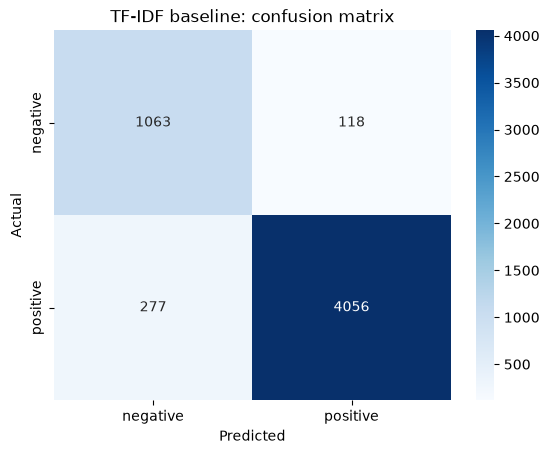

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_pred = clf.predict(X_test_vec)
print(classification_report(y_test, y_pred, target_names=["negative", "positive"], digits=3))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "positive"], yticklabels=["negative", "positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("TF-IDF baseline: confusion matrix")
plt.show()

## 7. Cross-validation

A single split can be lucky. 5-fold cross-validation on the full labeled set 
gives a more reliable estimate. The pipeline refits TF-IDF inside each fold.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

scores = cross_val_score(pipeline, X, y, cv=5, scoring="f1")
print(f"F1 per fold: {scores.round(3)}")
print(f"Mean: {scores.mean():.3f} (std {scores.std():.3f})")

F1 per fold: [0.95  0.95  0.953 0.952 0.954]
Mean: 0.952 (std 0.002)


## 8. Exports

The fitted baseline is saved for the Streamlit app, and a stratified 
10,000-review subset is exported for RoBERTa fine-tuning on GPU 
(see `02_roberta_finetuning.ipynb`).

In [20]:
import joblib
import os

os.makedirs("models", exist_ok=True)
joblib.dump(vectorizer, "models/tfidf_vectorizer.joblib")
joblib.dump(clf, "models/tfidf_logreg.joblib")

df_roberta, _ = train_test_split(
    df_labeled[["review", "label"]], train_size=10000,
    random_state=42, stratify=df_labeled["label"]
)
df_roberta.to_csv("data/reviews_roberta.csv", index=False)
print(f"Exported {len(df_roberta):,} reviews for fine-tuning")

Exported 10,000 reviews for fine-tuning
